### Open Ended Questions and Annotations v1

In [29]:
## what is the difference between open-ended and closed-ended questions?
## open-ended questions are questions that require more than a yes or no answer. They are designed to encourage a full, meaningful answer using the subject's own knowledge and/or feelings. Closed-ended questions can usually be answered with a simple "yes" or "no" answer. They are used to gather specific information.
# lets see some examples 

# open-ended question v1 
open_ended_question_json_path = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/datasets_/VQA/v1/questions/OpenEnded_mscoco_train2014_questions.json'

annotations_path = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/datasets_/VQA/v1/annotations/mscoco_train2014_annotations.json'

import json
with open(open_ended_question_json_path) as f:
    open_ended_questions = json.load(f)
    
with open(annotations_path) as f:
    data_ann = json.load(f)

    

In [30]:
print(open_ended_questions.keys())
print(data_ann.keys())

dict_keys(['info', 'task_type', 'data_type', 'license', 'data_subtype', 'questions'])
dict_keys(['info', 'data_type', 'license', 'data_subtype', 'annotations'])


In [31]:
print(open_ended_questions['questions'][0])
print(data_ann['annotations'][0])

# {'image_id': 458752, 'question': 'What is this photo taken looking through?', 'question_id': 458752000}
# {'question_type': 'what', 'multiple_choice_answer': 'curved', 'answers': [{'answer': 'oval', 'answer_confidence': 'yes', 'answer_id': 1}, {'answer': 'semi circle', 'answer_confidence': 'yes', 'answer_id': 2}, {'answer': 'curved', 'answer_confidence': 'yes', 'answer_id': 3}, {'answer': 'curved', 'answer_confidence': 'yes', 'answer_id': 4}, {'answer': 'double curve', 'answer_confidence': 'yes', 'answer_id': 5}, {'answer': 'banana', 'answer_confidence': 'maybe', 'answer_id': 6}, {'answer': 'curved', 'answer_confidence': 'yes', 'answer_id': 7}, {'answer': 'wavy', 'answer_confidence': 'yes', 'answer_id': 8}, {'answer': 'twisting', 'answer_confidence': 'no', 'answer_id': 9}, {'answer': 'curved', 'answer_confidence': 'maybe', 'answer_id': 10}], 'image_id': 487025, 'answer_type': 'other', 'question_id': 4870250}

{'question': 'What shape is the bench seat?', 'image_id': 487025, 'question_id': 4870250}
{'question_type': 'what', 'multiple_choice_answer': 'curved', 'answers': [{'answer': 'oval', 'answer_confidence': 'yes', 'answer_id': 1}, {'answer': 'semi circle', 'answer_confidence': 'yes', 'answer_id': 2}, {'answer': 'curved', 'answer_confidence': 'yes', 'answer_id': 3}, {'answer': 'curved', 'answer_confidence': 'yes', 'answer_id': 4}, {'answer': 'double curve', 'answer_confidence': 'yes', 'answer_id': 5}, {'answer': 'banana', 'answer_confidence': 'maybe', 'answer_id': 6}, {'answer': 'curved', 'answer_confidence': 'yes', 'answer_id': 7}, {'answer': 'wavy', 'answer_confidence': 'yes', 'answer_id': 8}, {'answer': 'twisting', 'answer_confidence': 'no', 'answer_id': 9}, {'answer': 'curved', 'answer_confidence': 'maybe', 'answer_id': 10}], 'image_id': 487025, 'answer_type': 'other', 'question_id': 4870250}


In [32]:
# get all the answers for the question
answers = [dict_['answer'] for dict_ in data_ann['annotations'][0]['answers']]
print(answers)
# how to get the answer that is most common
from collections import Counter
answer_counter = Counter(answers)
most_common_answer, count = answer_counter.most_common(1)[0]
print(f"The most common answer is '{most_common_answer}' with {count} occurrences.")


['oval', 'semi circle', 'curved', 'curved', 'double curve', 'banana', 'curved', 'wavy', 'twisting', 'curved']
The most common answer is 'curved' with 4 occurrences.


In [33]:
from collections import Counter

# Function to get the most common answer and its count
def get_most_common_answer(answers):
    answer_counter = Counter(answers)
    most_common_answer, count = answer_counter.most_common(1)[0]
    return most_common_answer, count

# data_ann = annotations
# Iterate through all annotations and check annotator agreement
agreement_results = []
for annotation in data_ann['annotations']:
    answers = [answer['answer'] for answer in annotation['answers']]
    most_common_answer, count = get_most_common_answer(answers)
    total_answers = len(answers)
    agreement_results.append({
        'question_id': annotation['question_id'],
        'most_common_answer': most_common_answer,
        'count': count,
        'total_answers': total_answers,
        'agreement': count / total_answers
    })

# # Print the results
# for result in agreement_results:
#     print(f"Question ID: {result['question_id']}, Most Common Answer: '{result['most_common_answer']}', Count: {result['count']}, Total Answers: {result['total_answers']}, Agreement: {result['agreement']:.2f}")

(array([  2603.,  10213.,  12540.,  13286.,  17231.,  18817.,  19612.,
         24098., 129949.]),
 array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]),
 <BarContainer object of 9 artists>)

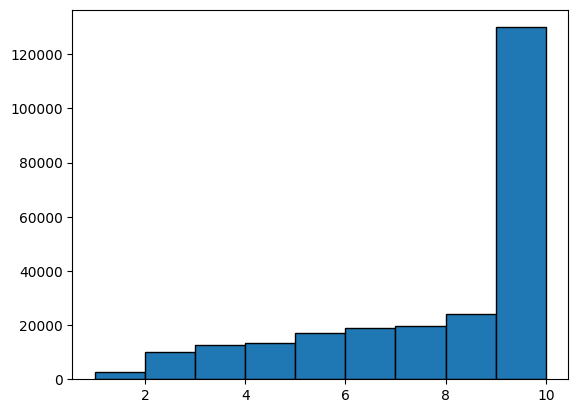

In [34]:
# agreement_results
# each agreement result is a dictionary with the following keys: 'question_id', 'most_common_answer', 'count', 'total_answers', 'agreement'
# {'question_id': 4870251,
#   'most_common_answer': 'yes',
#   'count': 10,
#   'total_answers': 10,
#   'agreement': 1.0},
# plot the agreement count for all the answers
import matplotlib.pyplot as plt

# Get the counts of the most common answers, count 
answer_counts = [result['count'] for result in agreement_results]

# Create a histogram of the answer counts
plt.hist(answer_counts, bins=range(1, max(answer_counts) + 1), edgecolor='black')

In [35]:
# answer_counts histogram
# (array([  2603.,  10213.,  12540.,  13286.,  17231.,  18817.,  19612.,
#          24098., 129949.]),
#  array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]),
#  <BarContainer object of 9 artists>)

# from above we can see that most of the answers have a count of 9 or 10
# lets choose the question ids that have a count of 9 or 10
question_ids = [result['question_id'] for result in agreement_results if result['count'] >= 9]
print(f"Number of questions with high agreement: {len(question_ids)}")

Number of questions with high agreement: 129949


In [36]:
# Number of questions with high agreement: 129949
# Lets print some of the questions with high agreement
# Each element of the open_ended_questions['questions'] is a dictionary with the following keys: 'image_id', 'question', 'question_id' : {'image_id': 458752, 'question': 'What is this photo taken looking through?', 'question_id': 458752000}

for question_id in question_ids[:5]:
    
    questions = [q for q in open_ended_questions['questions'] if q['question_id'] == question_id]
    if questions:
        print(questions[0]['question'])
    else:
        print(f"Question ID {question_id} not found in open_ended_questions.")

Is there a shadow?
Is this a modern train?
What color is the stripe on the train?
What is on the other side of the train?
Is the bus driver on any kind of antidepressant medication?


['what', 'is there a', 'is this', 'is this a', 'what color is the', 'what is on the', 'is the', 'is the', 'what color is the', 'are these', 'what is', 'is this a', 'is the', 'what is in the', 'where is the', 'what color are the', 'what', 'what', 'where are the', 'what animal is', 'none of the above', 'what kind of', 'what is the', 'is this', 'what', 'none of the above', 'are there any', 'what color is the', 'what color are the', 'what color is the', 'how', 'what', 'is the', 'what color is', 'how many', 'what color is the', 'why is the', 'who is', 'what kind of', 'what kind of', 'what color is the', 'are these', 'is the person', 'how many', 'what color', 'how many', 'what is', 'what kind of', 'is this a', 'where is the', 'what', 'is there a', 'is the', 'what kind of', 'what is the', 'what is', 'is there a', 'what color are the', 'does this', 'can you', 'what', 'what is this', 'none of the above', 'what is', 'does the', 'what color is the', 'is this person', 'is', 'which', 'is the man', 

In [48]:
# Now Lets anayze the question types and answer types
# get the question types
question_types = [annotation['question_type'] for annotation in data_ann['annotations']]
print(set(question_types)) 
print(len(set(question_types)))
print(Counter(question_types))

{'where are the', 'is the person', 'does the', 'is this person', 'what animal is', 'is the woman', 'who is', 'is it', 'what room is', 'is that a', 'what brand', 'what color', 'how', 'are they', 'does this', 'what sport is', 'do', 'what number is', 'what color are the', 'what is on the', 'is this', 'is there', 'what is the name', 'are', 'what is the color of the', 'what is this', 'what is in the', 'why is the', 'how many people are in', 'what does the', 'none of the above', 'can you', 'could', 'what is the person', 'where is the', 'are there any', 'was', 'is this a', 'what type of', 'why', 'what are the', 'do you', 'what', 'is there a', 'what kind of', 'what is the', 'is', 'what time', 'are the', 'what are', 'are there', 'what is the woman', 'what color is the', 'are these', 'how many people are', 'is this an', 'what is the man', 'is the man', 'has', 'what color is', 'which', 'what is', 'is he', 'is the', 'how many'}
65
Counter({'how many': 22224, 'is the': 20309, 'what': 19216, 'what c

In [47]:
print(len(set(question_types)))


65


In [ ]:
print(Counter(question_types))
# Counter({'how many': 22224, 'is the': 20309, 'what': 19216, 'what color is the': 15833, 'what is the': 13559, 'none of the above': 9744, 'is this': 9434, 'is this a': 8971, 'what is': 7439, 'are the': 6224, 'what kind of': 6173, 'is there a': 5352, 'what type of': 4390, 'is it': 4296, 'what are the': 3986, 'where is the': 3952, 'is there': 3581, 'is': 3510, 'does the': 3508, 'what color are the': 3425, 'are these': 3413, 'are there': 3169, 'which': 3014, 'what is the man': 2928, 'is the man': 2832, 'are': 2783, 'how': 2604, 'does this': 2458, 'what is on the': 2330, 'what does the': 2276, 'how many people are': 2234, 'what is in the': 2211, 'what is this': 2158, 'why': 2025, 'do': 1781, 'what are': 1768, 'are they': 1724, 'what time': 1671, 'what color': 1639, 'what sport is': 1543, 'are there any': 1499, 'is he': 1417, 'what color is': 1396, 'where are the': 1261, 'who is': 1237, 'what animal is': 1205, 'is the woman': 1130, 'is this an': 1112, 'do you': 1085, 'how many people are in': 1062, 'what room is': 1051, 'has': 1039, 'is this person': 993, 'what is the woman': 961, 'can you': 959, 'why is the': 957, 'is the person': 951, 'what is the color of the': 942, 'what is the person': 940, 'could': 936, 'was': 914, 'is that a': 911, 'what number is': 905, 'what is the name': 903, 'what brand': 896})

Counter({'how many': 22224, 'is the': 20309, 'what': 19216, 'what color is the': 15833, 'what is the': 13559, 'none of the above': 9744, 'is this': 9434, 'is this a': 8971, 'what is': 7439, 'are the': 6224, 'what kind of': 6173, 'is there a': 5352, 'what type of': 4390, 'is it': 4296, 'what are the': 3986, 'where is the': 3952, 'is there': 3581, 'is': 3510, 'does the': 3508, 'what color are the': 3425, 'are these': 3413, 'are there': 3169, 'which': 3014, 'what is the man': 2928, 'is the man': 2832, 'are': 2783, 'how': 2604, 'does this': 2458, 'what is on the': 2330, 'what does the': 2276, 'how many people are': 2234, 'what is in the': 2211, 'what is this': 2158, 'why': 2025, 'do': 1781, 'what are': 1768, 'are they': 1724, 'what time': 1671, 'what color': 1639, 'what sport is': 1543, 'are there any': 1499, 'is he': 1417, 'what color is': 1396, 'where are the': 1261, 'who is': 1237, 'what animal is': 1205, 'is the woman': 1130, 'is this an': 1112, 'do you': 1085, 'how many people are in'

In [50]:
# make a subset of the data_ann['annotations'] that only contains the question types in question_types_to_ground and has a high agreement
# Iterate through all annotations and check annotator agreement, and create a new file which follows the same format as the original file of data annotations

question_types_to_ground = [
    'which', 'what is the name', 'how', 'what color', 'what',
    'what room is', 'what number is', 'what is', 'what is this',
    'what is the man', 'what does the', 'where is the', 'what time',
    'what is on the', 'what are', 'what animal is', 'what is the person',
    'what is the', 'what kind of', 'what are the'
]

annotations_subset = []
for annotation in data_ann['annotations']:
    if annotation['question_type'] in question_types_to_ground and annotation['question_id'] in question_ids:
        annotations_subset.append(annotation)

# now check the agreement for the subset
agreement_results_subset = []
for annotation in annotations_subset:
    answers = [answer['answer'] for answer in annotation['answers']]
    most_common_answer, count = get_most_common_answer(answers)
    total_answers = len(answers)
    
    annotation['most_common_answer'] = most_common_answer
    annotation['count'] = count


In [56]:
# annotations_subset[:5]

# save this subset to a new file which conserves the same format as the original file of data annotations

output_path = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/datasets_/VQA/v1/annotations/mscoco_train2014_annotations_HIGH_agreement_question_types_GROUND.json'

data_ann.keys()
# dict_keys(['info', 'data_type', 'license', 'data_subtype', 'annotations'])

with open(output_path, 'w') as f:
    json.dump({
        'info': data_ann['info'],
        'data_type': data_ann['data_type'],
        'license': data_ann['license'],
        'data_subtype': data_ann['data_subtype'],
        'annotations': annotations_subset,
        'agreement': 'annotator agreement count >= 9',
        'question_types_to_ground': question_types_to_ground
    }, f)

In [58]:
# We filtered the annotations to only include the question types in question_types_to_ground and with a high agreement count. 
# Now do the same for the questions, but I think question subset can be done based on the question ids from the agreement_results_subset

question_ids_subset = [annotation['question_id'] for annotation in annotations_subset]

questions_subset = [question for question in open_ended_questions['questions'] if question['question_id'] in question_ids_subset]

output_path = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/datasets_/VQA/v1/questions/OpenEnded_mscoco_train2014_questions_HIGH_agreement_question_types_GROUND.json'

# open_ended_questions.keys()
# dict_keys(['info', 'task_type', 'data_type', 'license', 'data_subtype', 'questions'])
with open(output_path, 'w') as f:
    json.dump({'info': open_ended_questions['info'], 
               'task_type': open_ended_questions['task_type'], 'data_type': open_ended_questions['data_type'], 'license': open_ended_questions['license'], 'data_subtype': open_ended_questions['data_subtype'], 'questions': questions_subset, 
               'question_types_to_ground': question_types_to_ground}, f)
    

### Load the data, and take a look at the first few rows of the dataset

```python

In [1]:
import json 

In [2]:
path_questions = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/datasets_/VQA/v1/questions/OpenEnded_mscoco_train2014_questions_HIGH_agreement_question_types_GROUND.json'
path_annotations = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/datasets_/VQA/v1/annotations/mscoco_train2014_annotations_HIGH_agreement_question_types_GROUND.json'

In [3]:
# load the questions
with open(path_questions) as f:
    questions = json.load(f)
    
# load the annotations
with open(path_annotations) as f:
    annotations = json.load(f)

In [4]:
questions.keys()

dict_keys(['info', 'task_type', 'data_type', 'license', 'data_subtype', 'questions', 'question_types_to_ground'])

In [5]:
annotations.keys()

dict_keys(['info', 'data_type', 'license', 'data_subtype', 'annotations', 'agreement', 'question_types_to_ground'])

In [7]:
questions['questions'][:10]
# count the number of questions
print(f"Number of questions: {len(questions['questions'])}")

Number of questions: 25058


In [8]:
## After running random filter by running src/filter_data.py 
path_ = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/datasets_/VQA/v1/questions/OpenEnded_mscoco_train2014_questions_RANDOMSEED_42_COUNT_2000_CURRDATE_20241228_170848.json'

with open(path_) as f:
    questions = json.load(f)

In [10]:
questions['questions'][:10]

[{'question': 'What animal does the kite look like?',
  'image_id': 360931,
  'question_id': 3609311},
 {'question': 'What time is the clock representing?',
  'image_id': 325600,
  'question_id': 3256000},
 {'question': 'What spice is on the tomatoes?',
  'image_id': 302065,
  'question_id': 3020650},
 {'question': 'What object is the man sitting on?',
  'image_id': 37956,
  'question_id': 379560},
 {'question': "What is above the bird's head?",
  'image_id': 12805,
  'question_id': 128052},
 {'question': 'What is the name of the remote?',
  'image_id': 206489,
  'question_id': 2064892},
 {'question': 'What animal is shown?',
  'image_id': 137016,
  'question_id': 1370160},
 {'question': 'What is the girl eating?',
  'image_id': 14402,
  'question_id': 144020},
 {'question': 'What kind of room is this?',
  'image_id': 254787,
  'question_id': 2547871},
 {'question': 'What is the boy on?',
  'image_id': 377777,
  'question_id': 3777771}]

In [11]:
# count the number of questions
print(f"Number of questions: {len(questions['questions'])}")

Number of questions: 2000


In [1]:
# # there was an issue with the code above,
# [rank3]:   File "/home/tpadhi1/miniconda3/envs/llava/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 701, in __next__
# [rank3]:     data = self._next_data()
# [rank3]:   File "/home/tpadhi1/miniconda3/envs/llava/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 757, in _next_data
# [rank3]:     data = self._dataset_fetcher.fetch(index)  # may raise StopIteration
# [rank3]:   File "/home/tpadhi1/miniconda3/envs/llava/lib/python3.10/site-packages/torch/utils/data/_utils/fetch.py", line 52, in fetch
# [rank3]:     data = [self.dataset[idx] for idx in possibly_batched_index]
# [rank3]:   File "/home/tpadhi1/miniconda3/envs/llava/lib/python3.10/site-packages/torch/utils/data/_utils/fetch.py", line 52, in <listcomp>
# [rank3]:     data = [self.dataset[idx] for idx in possibly_batched_index]
# [rank3]:   File "/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/src2/data_utils.py", line 44, in __getitem__
# [rank3]:     self.question = self.question_data[question_id]['question']
# [rank3]: KeyError: 'question'
import json
path_questions = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/datasets_/VQA/v1/questions/OpenEnded_mscoco_train2014_questions_RANDOMSEED_42_COUNT_2000_CURRDATE_20241228_170848.json'

with open(path_questions) as f:
    questions = json.load(f)
    
questions['questions'][:10]



[{'question': 'What animal does the kite look like?',
  'image_id': 360931,
  'question_id': 3609311},
 {'question': 'What time is the clock representing?',
  'image_id': 325600,
  'question_id': 3256000},
 {'question': 'What spice is on the tomatoes?',
  'image_id': 302065,
  'question_id': 3020650},
 {'question': 'What object is the man sitting on?',
  'image_id': 37956,
  'question_id': 379560},
 {'question': "What is above the bird's head?",
  'image_id': 12805,
  'question_id': 128052},
 {'question': 'What is the name of the remote?',
  'image_id': 206489,
  'question_id': 2064892},
 {'question': 'What animal is shown?',
  'image_id': 137016,
  'question_id': 1370160},
 {'question': 'What is the girl eating?',
  'image_id': 14402,
  'question_id': 144020},
 {'question': 'What kind of room is this?',
  'image_id': 254787,
  'question_id': 2547871},
 {'question': 'What is the boy on?',
  'image_id': 377777,
  'question_id': 3777771}]

In [6]:
# so i ran the code, i have some files saved in /staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/runs_vqa/llava_vqa_yes_gsam_grounding_random_1000, now i want to analyze the results
# lets first check the files in the directory
import os
path = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/runs_vqa/llava_vqa_yes_gsam_grounding_random_1000/explanations'
files = os.listdir(path)
print(files)

# lets check the contents of the files
import json
import pickle
for file in files:
    with open(os.path.join(path, file), 'rb') as f:
        data = pickle.load(f)
        break

['explanations_3967431.pkl', 'explanations_3327320.pkl', 'explanations_4230971.pkl', 'explanations_3823162.pkl', 'explanations_1043680.pkl', 'explanations_2958041.pkl']


In [11]:
# if the key start with 'response' then it is the response from the model, print it out
for key in data.keys():
    if key.startswith('response'):
        print(key)
        # print(data[key])
        # print 3 keys, decoded_outputs, raw_decoded_outputs_llava, raw_decoded_outputs_llama2
        print("data[key]['decoded_outputs']", data[key]['decoded_outputs'])
        print("data[key]['raw_decoded_outputs_llava']", data[key]['raw_decoded_outputs_llava'])
        print("data[key]['raw_decoded_outputs_llama2']", data[key]['raw_decoded_outputs_llama2'])
        

response_0
data[key]['decoded_outputs'] The vase is on a table.
data[key]['raw_decoded_outputs_llava'] The vase is on a table.
data[key]['raw_decoded_outputs_llama2'] None
response_1
data[key]['decoded_outputs'] 
data[key]['raw_decoded_outputs_llava'] 
data[key]['raw_decoded_outputs_llama2'] None
response_2
data[key]['decoded_outputs'] 
data[key]['raw_decoded_outputs_llava'] Flower
data[key]['raw_decoded_outputs_llama2'] 
response_3
data[key]['decoded_outputs'] 
data[key]['raw_decoded_outputs_llava'] 
data[key]['raw_decoded_outputs_llama2'] None
response_4
data[key]['decoded_outputs'] The vase is on a dining table.
data[key]['raw_decoded_outputs_llava'] The vase is on a dining table.
data[key]['raw_decoded_outputs_llama2'] None
response_5
data[key]['decoded_outputs'] 
data[key]['raw_decoded_outputs_llava'] 
data[key]['raw_decoded_outputs_llama2'] None
response_6
data[key]['decoded_outputs'] 
data[key]['raw_decoded_outputs_llava'] 
data[key]['raw_decoded_outputs_llama2'] None
response_7

In [12]:
# response_0
# data[key]['decoded_outputs'] The vase is on a table.
# data[key]['raw_decoded_outputs_llava'] The vase is on a table.
# data[key]['raw_decoded_outputs_llama2'] None
# response_1
# data[key]['decoded_outputs'] 
# data[key]['raw_decoded_outputs_llava'] 
# data[key]['raw_decoded_outputs_llama2'] None
# response_2
# data[key]['decoded_outputs'] 
# data[key]['raw_decoded_outputs_llava'] Flower
# data[key]['raw_decoded_outputs_llama2'] 
# response_3
# data[key]['decoded_outputs'] 
# data[key]['raw_decoded_outputs_llava'] 
# data[key]['raw_decoded_outputs_llama2'] None
# response_4
# data[key]['decoded_outputs'] The vase is on a dining table.
# data[key]['raw_decoded_outputs_llava'] The vase is on a dining table.
# data[key]['raw_decoded_outputs_llama2'] None
# response_5
# data[key]['decoded_outputs'] 
# data[key]['raw_decoded_outputs_llava'] 
# data[key]['raw_decoded_outputs_llama2'] None
# response_6
# data[key]['decoded_outputs'] 
# data[key]['raw_decoded_outputs_llava'] 
# data[key]['raw_decoded_outputs_llama2'] None
# response_7
# data[key]['decoded_outputs'] 
# data[key]['raw_decoded_outputs_llava'] 
# data[key]['raw_decoded_outputs_llama2'] None
# response_8
# data[key]['decoded_outputs'] The vase is on a table.
# data[key]['raw_decoded_outputs_llava'] The vase is on a table.
# data[key]['raw_decoded_outputs_llama2'] None
# response_9
# data[key]['decoded_outputs'] 
# data[key]['raw_decoded_outputs_llava'] 
# data[key]['raw_decoded_outputs_llama2'] None
# response_10
# data[key]['decoded_outputs'] 
# data[key]['raw_decoded_outputs_llava'] 
# data[key]['raw_decoded_outputs_llama2'] None
# response_11
# data[key]['decoded_outputs'] 
# data[key]['raw_decoded_outputs_llava'] 
# data[key]['raw_decoded_outputs_llama2'] None
# response_12
# data[key]['decoded_outputs'] The vase is on the table.
# data[key]['raw_decoded_outputs_llava'] 1. Table
# data[key]['raw_decoded_outputs_llama2'] The vase is on the table.
# response_13
# data[key]['decoded_outputs'] 
# data[key]['raw_decoded_outputs_llava'] 
# data[key]['raw_decoded_outputs_llama2'] None
# response_14
# data[key]['decoded_outputs'] 
# data[key]['raw_decoded_outputs_llava'] 
# data[key]['raw_decoded_outputs_llama2'] None
# response_15
# data[key]['decoded_outputs'] 
# data[key]['raw_decoded_outputs_llava'] 
# data[key]['raw_decoded_outputs_llama2'] None
# response_16
# data[key]['decoded_outputs'] 
# data[key]['raw_decoded_outputs_llava'] Table
# data[key]['raw_decoded_outputs_llama2'] 
# response_17
# data[key]['decoded_outputs'] 
# data[key]['raw_decoded_outputs_llava'] 
# data[key]['raw_decoded_outputs_llama2'] None
# response_18
# data[key]['decoded_outputs'] 
# data[key]['raw_decoded_outputs_llava'] 
# data[key]['raw_decoded_outputs_llama2'] None
# response_19
# data[key]['decoded_outputs'] 
# data[key]['raw_decoded_outputs_llava'] 
# data[key]['raw_decoded_outputs_llama2'] None
# most of the responses are empty, only a few have some output, lets check the output of another file

# for file in files:
#     with open(os.path.join(path, file), 'rb') as f:
#         data = pickle.load(f)
#         break

path_expl = os.path.join(path, files[1])
with open(path_expl, 'rb') as f:
    data = pickle.load(f)

In [13]:
# if the key start with 'response' then it is the response from the model, print it out
for key in data.keys():
    if key.startswith('response'):
        print(key)
        # print(data[key])
        # print 3 keys, decoded_outputs, raw_decoded_outputs_llava, raw_decoded_outputs_llama2
        print("data[key]['decoded_outputs']", data[key]['decoded_outputs'])
        print("data[key]['raw_decoded_outputs_llava']", data[key]['raw_decoded_outputs_llava'])
        print("data[key]['raw_decoded_outputs_llama2']", data[key]['raw_decoded_outputs_llama2'])

response_0
data[key]['decoded_outputs'] 
data[key]['raw_decoded_outputs_llava'] 
data[key]['raw_decoded_outputs_llama2'] None
response_1
data[key]['decoded_outputs'] 
data[key]['raw_decoded_outputs_llava'] 
data[key]['raw_decoded_outputs_llama2'] None
response_2
data[key]['decoded_outputs'] 
data[key]['raw_decoded_outputs_llava'] 
data[key]['raw_decoded_outputs_llama2'] None
response_3
data[key]['decoded_outputs'] The red and white sign say "Stop."
data[key]['raw_decoded_outputs_llava'] The red and white sign say "Stop."
data[key]['raw_decoded_outputs_llama2'] None
response_4
data[key]['decoded_outputs'] 
data[key]['raw_decoded_outputs_llava'] 
data[key]['raw_decoded_outputs_llama2'] None
response_5
data[key]['decoded_outputs'] 
data[key]['raw_decoded_outputs_llava'] 
data[key]['raw_decoded_outputs_llama2'] None
response_6
data[key]['decoded_outputs'] 
data[key]['raw_decoded_outputs_llava'] 
data[key]['raw_decoded_outputs_llama2'] None
response_7
data[key]['decoded_outputs'] 
data[key]

In [14]:
# I removed the stop sequences from the model and ran again, lets see if thats causing the issue:

path = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/runs_vqa2/llava_vqa_yes_gsam_grounding_random_1000/explanations'
files = os.listdir(path)

path_expl = os.path.join(path, files[0])
with open(path_expl, 'rb') as f:
    data = pickle.load(f)



In [15]:
# if the key start with 'response' then it is the response from the model, print it out, this time the output should be different
for key in data.keys():
    if key.startswith('response'):
        print(key)
        # print(data[key])
        # print 3 keys, decoded_outputs, raw_decoded_outputs_llava, raw_decoded_outputs_llama2
        print("data[key]['decoded_outputs']", data[key]['decoded_outputs'])
        print("data[key]['raw_decoded_outputs_llava']", data[key]['raw_decoded_outputs_llava'])
        print("data[key]['raw_decoded_outputs_llama2']", data[key]['raw_decoded_outputs_llama2'])

response_0
data[key]['decoded_outputs'] 
data[key]['raw_decoded_outputs_llava'] 
data[key]['raw_decoded_outputs_llama2'] None
response_1
data[key]['decoded_outputs'] 
data[key]['raw_decoded_outputs_llava'] 
data[key]['raw_decoded_outputs_llama2'] None
response_2
data[key]['decoded_outputs'] 
data[key]['raw_decoded_outputs_llava'] Vase
data[key]['raw_decoded_outputs_llama2'] 
response_3
data[key]['decoded_outputs'] 
data[key]['raw_decoded_outputs_llava'] 
data[key]['raw_decoded_outputs_llama2'] None
response_4
data[key]['decoded_outputs'] 
data[key]['raw_decoded_outputs_llava'] 
data[key]['raw_decoded_outputs_llama2'] None
response_5
data[key]['decoded_outputs'] The vase is sitting on top of a wooden dining room table.
data[key]['raw_decoded_outputs_llava'] The vase is sitting on top of a wooden dining room table.
data[key]['raw_decoded_outputs_llama2'] None
response_6
data[key]['decoded_outputs'] The vase is on a table.
data[key]['raw_decoded_outputs_llava'] The vase is on a table.
dat

In [10]:
# ok so i tried to run the model in full precision, lets see if that works
import os 
import pickle
path = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/runs_vqa3/llava_vqa_yes_gsam_grounding_random_1000/explanations'
files = os.listdir(path)

path_expl = os.path.join(path, files[0])
with open(path_expl, 'rb') as f:
    data = pickle.load(f)

In [11]:
data.keys()
# there will be response keys, lets check the output
for key in data.keys():
    if key.startswith('response'):
        print(key)
        print("data[key]['decoded_outputs']", data[key]['decoded_outputs'])
        # print("data_expl_3[key]['raw_decoded_outputs_llava']", data_expl_3[key]['raw_decoded_outputs_llava'])
        # print("data_expl_3[key]['raw_decoded_outputs_llama2']", data_expl_3[key]['raw_decoded_outputs_llama2'])
# data_expl_3['response_0']
# 'decoded_outputs' is the key

response_0
data[key]['decoded_outputs'] 
response_1
data[key]['decoded_outputs'] 
response_2
data[key]['decoded_outputs'] 
response_3
data[key]['decoded_outputs'] 
response_4
data[key]['decoded_outputs'] 
response_5
data[key]['decoded_outputs'] ➡️ A countertop
response_6
data[key]['decoded_outputs'] Table
response_7
data[key]['decoded_outputs'] Chair
response_8
data[key]['decoded_outputs'] The vase is on a table.
response_9
data[key]['decoded_outputs'] 
response_10
data[key]['decoded_outputs'] Dining table
response_11
data[key]['decoded_outputs'] 
response_12
data[key]['decoded_outputs'] 1. Coffee table
response_13
data[key]['decoded_outputs'] 
response_14
data[key]['decoded_outputs'] 
response_15
data[key]['decoded_outputs'] The vase is on a table.
response_16
data[key]['decoded_outputs'] 
response_17
data[key]['decoded_outputs'] 1. Table
response_18
data[key]['decoded_outputs'] 
response_19
data[key]['decoded_outputs'] 答


In [4]:
# ok, so even after running the model in full precision, the output is still empty, lets check the model output here, and lets see if the temperature is causing the issue, so i did a test run with temperatures and without temperatures, and prompt with ICL and without ICL, lets see if the output is different

import pickle
path_ = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/runs_vqa3/llava_vqa_yes_gsam_grounding_random_1000/explanations/explanations_5809710.pkl'

with open(path_, 'rb') as f:

    data = pickle.load(f)

In [10]:
from transformers import AutoProcessor

model_id_llava = "llava-hf/llava-1.5-7b-hf"
processor_llava = AutoProcessor.from_pretrained(model_id_llava)

# for every key in data, if the key starts with 'response' do the below
for key in data.keys():
    if key.startswith('response'):
        print(key)
        gen_token_ids = data[key]['generated_token_ids']       
        # Decode the generated token IDs
        decoded_output = processor_llava.decode(gen_token_ids, skip_special_tokens=True)        
        print(decoded_output)
        print('_'*100)


Some kwargs in processor config are unused and will not have any effect: num_additional_image_tokens. 


response_0
USER: Answer the questions. Here are few examples:
        Question: What is the color of the object?
        Answer: The color of the object is red.
        Question: What are the people doing ?
        Answer: The people in the image are playing soccer.
        Question: What animal is in the image?
        Answer: The animal is a cat.
        
         
        What television channel was this taken from?
        ASSISTANT: 
        
        I could not determine with certainty which television channel this image was taken from because it could be a scene from various TV shows or movies and might involve different settings. The image portrays a man or a man-like figure wearing headdress and a mask, possibly as part of a costume or character in a TV show or movie. The specific channel would depend on the context in which this scene is presented.
____________________________________________________________________________________________________
response_1
USER: Answer the 

In [ ]:
# I want to take the response after ASSISTANT: so i will split the string by ASSISTANT: and take the second part, i should do this? or should i get the token id of ASSISTANT: and then take the next token id and then decode it, lets try both Answer: I will try the second approach

# get the token id of ASSISTANT:
processor_llava.tokenizer.tokenize('ASSISTANT:')

['▁A', 'SS', 'IST', 'ANT', ':']

In [20]:
# # check if the token id is in the generated token ids of the first response
# gen_token_ids = data['response_0']['generated_token_ids']
# token_id = processor_llava.tokenizer.convert_tokens_to_ids('ASSISTANT')
# print(token_id)
# print(gen_token_ids)
# print(token_id in gen_token_ids)

# generated_tokens = processor_llava.decode(gen_token_ids, skip_special_tokens=True)
# # for i in range(len(gen_token_ids)):
# #     # if gen_token_ids[i] == token_id:
# #     print(i)
# #     print(gen_token_ids[i+1])
# #     print(processor_llava.tokenizer.decode(gen_token_ids[i+1]))


In [12]:
# for every key in data, if the key starts with 'response' do the below
assistant_token_id = 0 
for key in data.keys():
    if key.startswith('response'):
        print(key)
        gen_token_ids = data[key]['generated_token_ids']       
        # Decode the generated token IDs
        # filter the token ids after ASSISTANT:
        gen_token_ids_filtered = []
        # get the array position of the token id of ASSISTANT:
        for i, token_id in enumerate(gen_token_ids):
            if token_id == assistant_token_id:
                assistant_token_id_position = i
                break
        # get the token ids after the assistant token id
        gen_token_ids_filtered = gen_token_ids[assistant_token_id_position+1:]
        decoded_output = processor_llava.decode(gen_token_ids_filtered, skip_special_tokens=True)        
        print(decoded_output)
        print('_'*100)

response_0


NameError: name 'assistant_token_id_position' is not defined

In [21]:
# decoded_output_llava

# '<s> USER: Answer the questions. Here are few examples:\n        Question: What is the color of the object?\n        Answer: The color of the object is red.\n        Question: What are the people doing ?\n        Answer: The people in the image are playing soccer.\n        Question: What animal is in the image?\n        Answer: The animal is a cat.\n        \n        <image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image> \n        What television channel was this taken from?\n        ASSISTANT: \n        \n        I could not determine with certainty which television channel this image was taken from because it could be a scene from various TV shows or movies and might involve different settings. The image portrays a man or a man-like figure wearing headdress and a mask, possibly as part of a costume or character in a TV show or movie. The specific channel would depend on the context in which this scene is presented.</s>'

In [3]:
# data
# print the key which starts with response
for key in data.keys():
    if key.startswith('response'):
        print(key)
        print("data[key]['decoded_outputs']", data[key]['decoded_outputs'])
        # print("data[key]['raw_decoded_outputs_llava']", data[key]['raw_decoded_outputs_llava'])
        # print("data[key]['raw_decoded_outputs_llama2']", data[key]['raw_decoded_outputs_llama2'])

response_0
data[key]['decoded_outputs'] USER: Answer the questions. Here are few examples:
response_1
data[key]['decoded_outputs'] USER: Answer the questions. Here are few examples:
response_2
data[key]['decoded_outputs'] USER: Answer the questions. Here are few examples:
response_3
data[key]['decoded_outputs'] USER: Answer the questions. Here are few examples:
response_4
data[key]['decoded_outputs'] USER: Answer the questions. Here are few examples:
response_5
data[key]['decoded_outputs'] USER: Answer the questions. Here are few examples:
response_6
data[key]['decoded_outputs'] USER: Answer the questions. Here are few examples:
response_7
data[key]['decoded_outputs'] USER: Answer the questions. Here are few examples:
response_8
data[key]['decoded_outputs'] USER: Answer the questions. Here are few examples:
response_9
data[key]['decoded_outputs'] USER: Answer the questions. Here are few examples:
response_10
data[key]['decoded_outputs'] USER: Answer the questions. Here are few examples

In [22]:
# ok so now what i did was i removed the stop sequences and also taking the responses without new line characters, lets see if that works

path = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/runs_vqa4/llava_vqa_yes_gsam_grounding_random_1000/explanations/explanations_404552.pkl'
import pickle
with open(path, 'rb') as f:
    data = pickle.load(f)

In [29]:
# for every key in data, if the key starts with 'response' do the below
for key in data.keys():
    if key.startswith('response'):
        print(key)
        print("data[key]['decoded_outputs'] ------- ", data[key]['decoded_outputs'])
        print("data[key]['decoded_outputs'] after stripping -----", data[key]['decoded_outputs'].strip())
        print("data[key]['decoded_outputs'] after new line filter and then stripping -----", data[key]['decoded_outputs'].split('\n')[0].strip())
        print("data[key]['decoded_outputs'] after stripping and new line filter -----", data[key]['decoded_outputs'].strip().split('\n')[0])
        # print("data[key]['raw_decoded_outputs_llava
        print("-"*100)
        # print("data[key]['raw_decoded_outputs_llava']", data[key]['raw_decoded_outputs_llava'])
        # print("data[key]['raw_decoded_outputs_llama2']", data[key]['raw_decoded_outputs_llama2'])

response_0
data[key]['decoded_outputs'] -------  These are ducks.
data[key]['decoded_outputs'] after stripping ----- These are ducks.
data[key]['decoded_outputs'] after new line filter and then stripping ----- These are ducks.
data[key]['decoded_outputs'] after stripping and new line filter ----- These are ducks.
----------------------------------------------------------------------------------------------------
response_1
data[key]['decoded_outputs'] -------  
        
 Ducks
data[key]['decoded_outputs'] after stripping ----- Ducks
data[key]['decoded_outputs'] after new line filter and then stripping ----- 
data[key]['decoded_outputs'] after stripping and new line filter ----- Ducks
----------------------------------------------------------------------------------------------------
response_2
data[key]['decoded_outputs'] -------  
        Based on the visual clues – standing in a row with heads looking forward, and facing the same direction – these animals could be ducks or geese. The

In [30]:
# yes so this works, now i will run the model with the stop sequences and without the new line characters, and then i will analyze the output
# so strip takes care of the leading and trailing white spaces, and then a split('\n') will split the string by new line characters, and then i can take the first element of the list which would be the response.

In [40]:
# path = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/runs_vqa5/llava_vqa_yes_gsam_grounding_random_1000/explanations/explanations_3327320.pkl'
# path = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/runs_vqa5/llava_vqa_yes_gsam_grounding_random_1000/explanations/explanations_2958041.pkl'
path = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/runs_vqa5/llava_vqa_yes_gsam_grounding_random_1000/explanations/explanations_5755300.pkl'
import pickle
with open(path, 'rb') as f:
    data = pickle.load(f)

In [41]:
# for every key in data, if the key starts with 'response' do the below
for key in data.keys():
    if key.startswith('response'):
        print(key)
        print("data[key]['decoded_outputs'] ------- ", data[key]['decoded_outputs'])
        # print("data[key]['decoded_outputs'] after stripping -----", data[key]['decoded_outputs'].strip())
        # print("data[key]['decoded_outputs'] after new line filter and then stripping -----", data[key]['decoded_outputs'].split('\n')[0].strip())
        # print("data[key]['decoded_outputs'] after stripping and new line filter -----", data[key]['decoded_outputs'].strip().split('\n')[0])
        # print("data[key]['raw_decoded_outputs_llava
        print("data[key]['raw_decoded_outputs_llava']", data[key]['raw_decoded_outputs_llava'])
        print("data[key]['raw_decoded_outputs_llama2']", data[key]['raw_decoded_outputs_llama2'])
        print("-"*100)
# the below problem was for # path = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/runs_vqa5/llava_vqa_yes_gsam_grounding_random_1000/explanations/explanations_2958041.pkl'
    
## Llama2 is not working, lets check the output of llama2
# response_4
# data[key]['decoded_outputs'] -------  In this example, the model is able to answer the questions correctly, and the LLAMA2 response is "The animal shown is a dog." for the first question, and "The girl is eating an apple." for
# data[key]['raw_decoded_outputs_llava'] 18
# data[key]['raw_decoded_outputs_llama2'] In this example, the model is able to answer the questions correctly, and the LLAMA2 response is "The animal shown is a dog." for the first question, and "The girl is eating an apple." for
# ----------------------------------------------------------------------------------------------------
# response_5
# data[key]['decoded_outputs'] -------  In this example, the model is able to answer the questions correctly, and the LLAMA2 response is "The animal shown is a dog." for the first question, and "The girl is eating an apple." for
# data[key]['raw_decoded_outputs_llava'] 18
# data[key]['raw_decoded_outputs_llama2'] In this example, the model is able to answer the questions correctly, and the LLAMA2 response is "The animal shown is a dog." for the first question, and "The girl is eating an apple." for
# ----------------------------------------------------------------------------------------------------
# response_6
# data[key]['decoded_outputs'] -------  Question: How would you describe the person's hair style?
# data[key]['raw_decoded_outputs_llava'] Question: How would you describe the person's hair style?
# data[key]['raw_decoded_outputs_llama2'] None
# ----------------------------------------------------------------------------------------------------
# response_7
# data[key]['decoded_outputs'] -------  In this example, the model is able to answer the questions correctly, and the LLAMA2 response is "The animal shown is a dog." for the first question, and "The girl is eating an apple." for
# data[key]['raw_decoded_outputs_llava'] 18
# data[key]['raw_decoded_outputs_llama2'] In this example, the model is able to answer the questions correctly, and the LLAMA2 response is "The animal shown is a dog." for the first question, and "The girl is eating an apple." for
# ----------------------------------------------------------------------------------------------------
# response_8

response_0
data[key]['decoded_outputs'] -------  The animal shown is a dog.
data[key]['raw_decoded_outputs_llava'] Bathroom
data[key]['raw_decoded_outputs_llama2'] The animal shown is a dog.
----------------------------------------------------------------------------------------------------
response_1
data[key]['decoded_outputs'] -------  The animal shown is a dog.
data[key]['raw_decoded_outputs_llava'] Bathroom
data[key]['raw_decoded_outputs_llama2'] The animal shown is a dog.
----------------------------------------------------------------------------------------------------
response_2
data[key]['decoded_outputs'] -------  The animal shown is a dog.
data[key]['raw_decoded_outputs_llava'] Bathroom
data[key]['raw_decoded_outputs_llama2'] The animal shown is a dog.
----------------------------------------------------------------------------------------------------
response_3
data[key]['decoded_outputs'] -------  The animal shown is a dog.
data[key]['raw_decoded_outputs_llava'] Bathroom


In [1]:
path = '/home/ubuntu/trilok/Multimodal-Uncertainty-Quantification/runs_vqa6/llava_vqa_yes_gsam_grounding_random_1000/explanations/explanations_3327320.pkl'
import pickle
with open(path, 'rb') as f:
    data = pickle.load(f)
    

In [2]:
# for every key in data, if the key starts with 'response' do the below
for key in data.keys():
    if key.startswith('response'):
        print(key)
        print("data[key]['decoded_outputs'] ------- ", data[key]['decoded_outputs'])
        # print("data[key]['decoded_outputs'] after stripping -----", data[key]['decoded_outputs'].strip())
        # print("data[key]['decoded_outputs'] after new line filter and then stripping -----", data[key]['decoded_outputs'].split('\n')[0].strip())
        # print("data[key]['decoded_outputs'] after stripping and new line filter -----", data[key]['decoded_outputs'].strip().split('\n')[0])
        # print("data[key]['raw_decoded_outputs_llava
        # print("data[key]['raw_decoded_outputs_llava']", data[key]['raw_decoded_outputs_llava'])
        # print("data[key]['raw_decoded_outputs_llama2']", data[key]['raw_decoded_outputs_llama2'])
        print("-"*100)

response_0
data[key]['decoded_outputs'] -------  
        The red and white sign says "STOP", with a single letter missing "P".
----------------------------------------------------------------------------------------------------
response_1
data[key]['decoded_outputs'] -------  
        The red and white sign says "Stop" in white letters.
----------------------------------------------------------------------------------------------------
response_2
data[key]['decoded_outputs'] -------  
        The red and white sign says "STOP."
----------------------------------------------------------------------------------------------------
response_3
data[key]['decoded_outputs'] -------  
        The red and white sign says "STOP."
----------------------------------------------------------------------------------------------------
response_4
data[key]['decoded_outputs'] -------  
        The red and white sign says "STOP."
---------------------------------------------------------------------------

In [5]:
path = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/datasets_/VQA/v2/questions/v2_OpenEnded_mscoco_train2014_questions_random_2000_20241227_20241227_034402.json'

import json

with open(path, 'r') as f:
    data = json.load(f)
    
print(data.keys())

dict_keys(['info', 'task_type', 'data_type', 'license', 'data_subtype', 'questions'])


### closed-ended question v1


In [20]:
multiple_choice_data_path = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/datasets_/VQA/v1/questions/MultipleChoice_mscoco_train2014_questions.json'

annotations_path_v1 = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/datasets_/VQA/v1/annotations/mscoco_train2014_annotations.json'
with open(multiple_choice_data_path, 'r') as f:
    multiple_choice_data = json.load(f)
    
with open(annotations_path_v1, 'r') as f:
    annotations_v1 = json.load(f)

In [16]:
multiple_choice_data.keys()

dict_keys(['info', 'task_type', 'data_type', 'license', 'questions', 'data_subtype', 'num_choices'])

In [19]:
multiple_choice_data['questions'][0]
# there are 18 choices 

{'image_id': 487025,
 'question': 'What shape is the bench seat?',
 'multiple_choices': ['square',
  '1',
  'w 26th st',
  'white',
  'rectangular',
  '2',
  'red',
  '3',
  'blue',
  '4',
  'yellow sign',
  'curved',
  'green',
  'no',
  'rectangle',
  'croatia express',
  'medal',
  'yes'],
 'question_id': 4870250}

In [21]:
annotations_v1['annotations'][0]

{'question_type': 'what',
 'multiple_choice_answer': 'curved',
 'answers': [{'answer': 'oval', 'answer_confidence': 'yes', 'answer_id': 1},
  {'answer': 'semi circle', 'answer_confidence': 'yes', 'answer_id': 2},
  {'answer': 'curved', 'answer_confidence': 'yes', 'answer_id': 3},
  {'answer': 'curved', 'answer_confidence': 'yes', 'answer_id': 4},
  {'answer': 'double curve', 'answer_confidence': 'yes', 'answer_id': 5},
  {'answer': 'banana', 'answer_confidence': 'maybe', 'answer_id': 6},
  {'answer': 'curved', 'answer_confidence': 'yes', 'answer_id': 7},
  {'answer': 'wavy', 'answer_confidence': 'yes', 'answer_id': 8},
  {'answer': 'twisting', 'answer_confidence': 'no', 'answer_id': 9},
  {'answer': 'curved', 'answer_confidence': 'maybe', 'answer_id': 10}],
 'image_id': 487025,
 'answer_type': 'other',
 'question_id': 4870250}

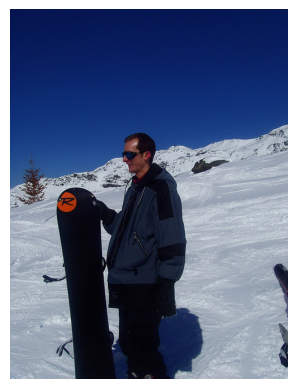

In [ ]:
data['questions']

## there was a question - what is the man thinkin ?
# 'image_id': 267830,
#   'question': 'What is this man thinking?',
#   'question_id': 267830001},
# visualize the image

image_dir = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/datasets_/VQA/train2014'
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread(f'{image_dir}/COCO_train2014_000000267830.jpg')
plt.imshow(img)
plt.axis('off')  # Hide axes
plt.show()

In [7]:
# load the annotations
path = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/datasets_/VQA/v2/annotations/v2_mscoco_train2014_annotations.json'

with open(path, 'r') as f:
    data_ann = json.load(f)

In [8]:
data_ann.keys()

dict_keys(['info', 'license', 'data_subtype', 'annotations', 'data_type'])

In [ ]:
data_ann['annotations']

# each annoation is of the below format:
# {'question_type': 'what is this',
#   'multiple_choice_answer': 'net',
#   'answers': [{'answer': 'net', 'answer_confidence': 'maybe', 'answer_id': 1},
#    {'answer': 'net', 'answer_confidence': 'yes', 'answer_id': 2},
#    {'answer': 'net', 'answer_confidence': 'yes', 'answer_id': 3},
#    {'answer': 'netting', 'answer_confidence': 'yes', 'answer_id': 4},
#    {'answer': 'net', 'answer_confidence': 'yes', 'answer_id': 5},
#    {'answer': 'net', 'answer_confidence': 'yes', 'answer_id': 6},
#    {'answer': 'mesh', 'answer_confidence': 'maybe', 'answer_id': 7},
#    {'answer': 'net', 'answer_confidence': 'yes', 'answer_id': 8},
#    {'answer': 'net', 'answer_confidence': 'yes', 'answer_id': 9},
#    {'answer': 'net', 'answer_confidence': 'yes', 'answer_id': 10}],
#   'image_id': 458752,
#   'answer_type': 'other',
#   'question_id': 458752000},
# lets see the answers for the questiion id 267830001

ann_ = [ann for ann in data_ann['annotations'] if ann['question_id'] == 267830001]
ann_

[{'question_type': 'what is this',
  'multiple_choice_answer': 'its cold',
  'answers': [{'answer': 'its cold',
    'answer_confidence': 'maybe',
    'answer_id': 1},
   {'answer': 'skiing', 'answer_confidence': 'yes', 'answer_id': 2},
   {'answer': "that's long way down",
    'answer_confidence': 'no',
    'answer_id': 3},
   {'answer': "i don't know", 'answer_confidence': 'yes', 'answer_id': 4},
   {'answer': 'beautiful day', 'answer_confidence': 'no', 'answer_id': 5},
   {'answer': 'logic', 'answer_confidence': 'maybe', 'answer_id': 6},
   {'answer': "evaluating someone's performance",
    'answer_confidence': 'maybe',
    'answer_id': 7},
   {'answer': 'how best to approach slope',
    'answer_confidence': 'maybe',
    'answer_id': 8},
   {'answer': 'its cold', 'answer_confidence': 'yes', 'answer_id': 9},
   {'answer': 'that he is cold', 'answer_confidence': 'no', 'answer_id': 10}],
  'image_id': 267830,
  'answer_type': 'other',
  'question_id': 267830001}]

NameError: name 'data_ann' is not defined